In [1]:
import numpy as np
import pandas as pd
from IPython.core.completerlib import import_re
from mpl_toolkits.mplot3d.art3d import rotate_axes

In [2]:
df = pd.read_csv(r'C:\Users\muzam\Downloads\DPS\screen_time_mental_health.csv')

In [3]:
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64

In [6]:
df.nunique()

subject_id                  4810
sex                            2
screen_time_index             16
est_leisure_screen_hours      32
sleep_quality_index           21
avg_sleep_hours              608
midsleep_weekend_hours       400
social_jetlag_hours          382
bdi_total                     51
depressed                      2
dtype: int64

In [7]:
df.shape

(4810, 10)

In [8]:
(df['subject_id'] < 0 ).sum()

np.int64(0)

In [9]:
(df['screen_time_index'] < 0).sum()

np.int64(0)

In [10]:
(df['est_leisure_screen_hours'] < 0).sum()

np.int64(0)

In [11]:
(df['sleep_quality_index'] < 0).sum()

np.int64(0)

In [12]:
(df['avg_sleep_hours'] < 0).sum()

np.int64(0)

In [13]:
(df['midsleep_weekend_hours'] < 0).sum()

np.int64(0)

In [14]:
(df['social_jetlag_hours'] < 0).sum()

np.int64(38)

In [15]:
(df['bdi_total'] < 0).sum()

np.int64(0)

In [16]:
(df['depressed'] < 0).sum()

np.int64(0)

In [17]:
df['social_jetlag_hours']

0       1.92
1       2.25
2       2.62
3       3.96
4       1.79
        ... 
4805    2.00
4806    3.46
4807    1.62
4808    2.83
4809    4.12
Name: social_jetlag_hours, Length: 4810, dtype: float64

In [18]:
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [19]:
df = df.drop(columns=['subject_id'])

In [21]:
df.head()

,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [23]:
df.shape

(4810, 9)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex                       4810 non-null   str    
 1   screen_time_index         4810 non-null   float64
 2   est_leisure_screen_hours  4810 non-null   float64
 3   sleep_quality_index       4810 non-null   float64
 4   avg_sleep_hours           4810 non-null   float64
 5   midsleep_weekend_hours    4810 non-null   float64
 6   social_jetlag_hours       4810 non-null   float64
 7   bdi_total                 4810 non-null   int64  
 8   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 338.3 KB


In [26]:
df['depressed'].value_counts(normalize=True) * 100

depressed
0    83.638254
1    16.361746
Name: proportion, dtype: float64

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
screen_time_index,4810.0,3.219097,1.026348,1.00,2.333,3.00,4.00,6.00
est_leisure_screen_hours,4810.0,3.958299,2.387289,0.50,2.070,3.50,5.50,10.00
sleep_quality_index,4810.0,1.901611,0.851176,1.00,1.250,1.75,2.25,6.00
avg_sleep_hours,4810.0,7.689067,1.270213,1.36,7.050,7.87,8.54,12.21
midsleep_weekend_hours,4810.0,5.570553,1.415505,1.67,4.540,5.42,6.50,10.50
social_jetlag_hours,4810.0,2.400200,1.137931,-3.03,1.580,2.29,3.12,6.96
bdi_total,4810.0,7.271518,7.703156,0.00,2.000,5.00,10.00,51.00
depressed,4810.0,0.163617,0.369967,0.00,0.000,0.00,0.00,1.00


In [31]:
df.nunique()

sex                           2
screen_time_index            16
est_leisure_screen_hours     32
sleep_quality_index          21
avg_sleep_hours             608
midsleep_weekend_hours      400
social_jetlag_hours         382
bdi_total                    51
depressed                     2
dtype: int64

In [33]:
df['sex'].value_counts()

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

In [34]:
df['sex'].value_counts(normalize=True) * 100

sex
Boy     50.852391
Girl    49.147609
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

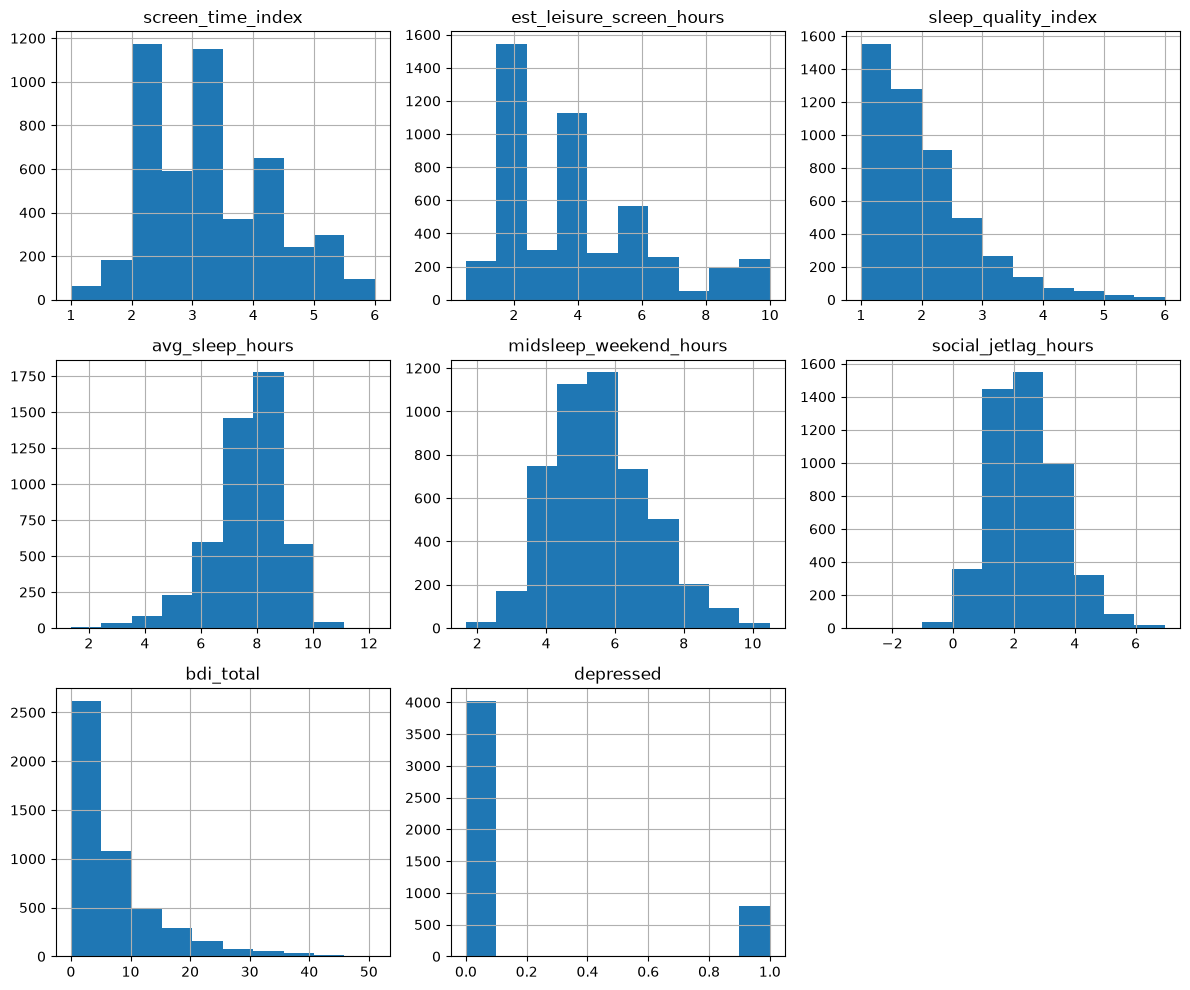

In [37]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show

In [38]:
df.groupby('depressed')['est_leisure_screen_hours'].mean()

depressed
0    3.888422
1    4.315502
Name: est_leisure_screen_hours, dtype: float64

In [39]:
df.groupby('depressed')['avg_sleep_hours'].mean()

depressed
0    7.797823
1    7.133126
Name: avg_sleep_hours, dtype: float64

In [43]:
df.groupby('depressed')['sleep_quality_index'].mean()

depressed
0    1.784241
1    2.501588
Name: sleep_quality_index, dtype: float64

In [44]:
df.groupby('depressed')['social_jetlag_hours'].mean()

depressed
0    2.369667
1    2.556277
Name: social_jetlag_hours, dtype: float64

In [45]:
corr =  df.corr(numeric_only=True)
corr

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
screen_time_index,1.000000,0.935067,0.092327,-0.256280,0.286531,0.182000,0.134377,0.090661
est_leisure_screen_hours,0.935067,1.000000,0.071959,-0.227361,0.264168,0.164165,0.107172,0.066186
sleep_quality_index,0.092327,0.071959,1.000000,-0.318088,0.124462,0.022253,0.380581,0.311798
avg_sleep_hours,-0.256280,-0.227361,-0.318088,1.000000,-0.517585,-0.163678,-0.260253,-0.193602
midsleep_weekend_hours,0.286531,0.264168,0.124462,-0.517585,1.000000,0.837755,0.148764,0.119636
social_jetlag_hours,0.182000,0.164165,0.022253,-0.163678,0.837755,1.000000,0.071679,0.060671
bdi_total,0.134377,0.107172,0.380581,-0.260253,0.148764,0.071679,1.000000,0.815114
depressed,0.090661,0.066186,0.311798,-0.193602,0.119636,0.060671,0.815114,1.000000


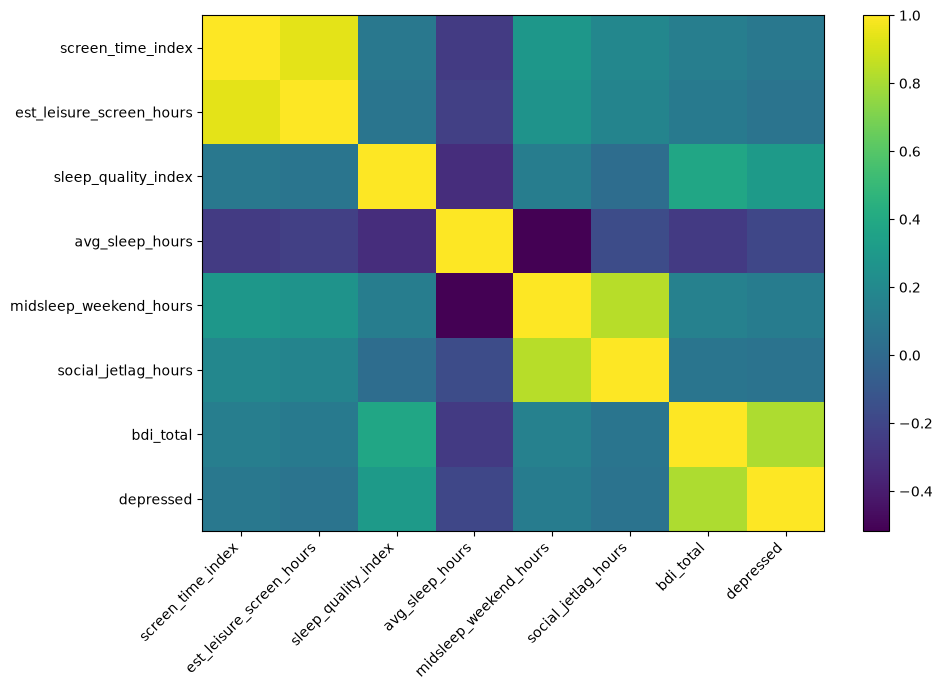

In [46]:
plt.figure(figsize=(10,7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

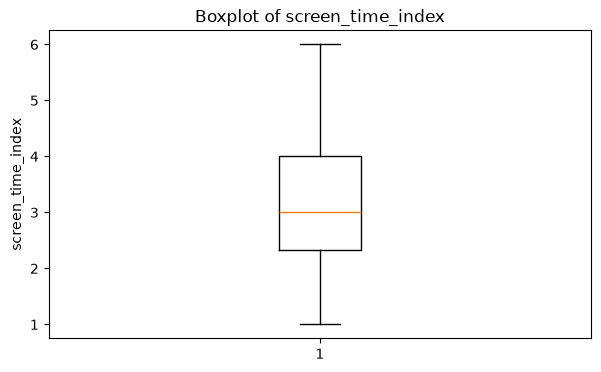

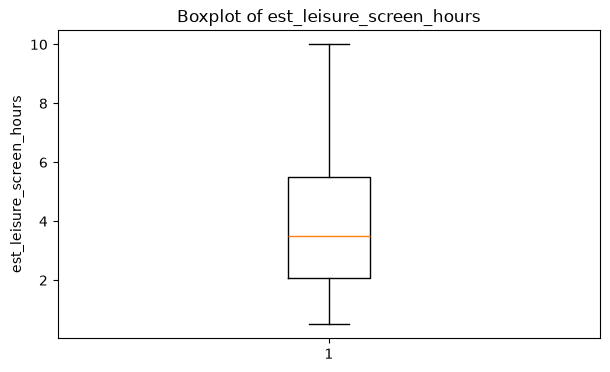

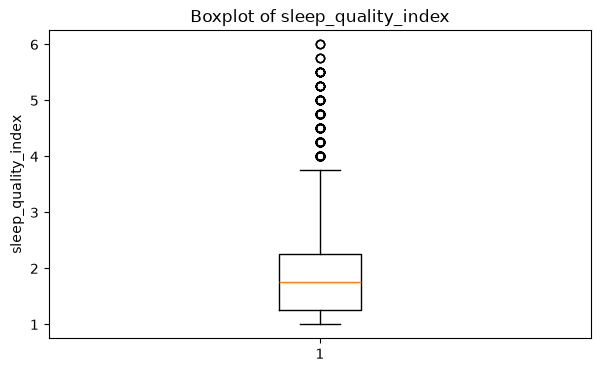

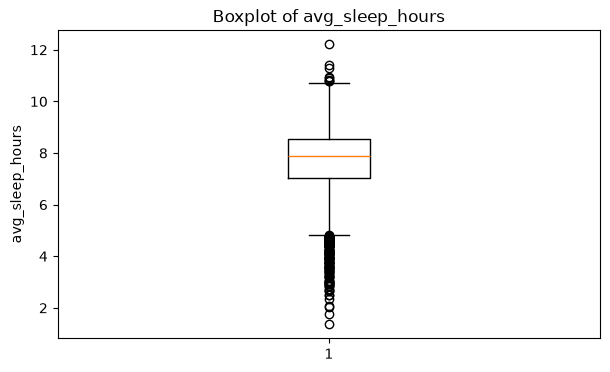

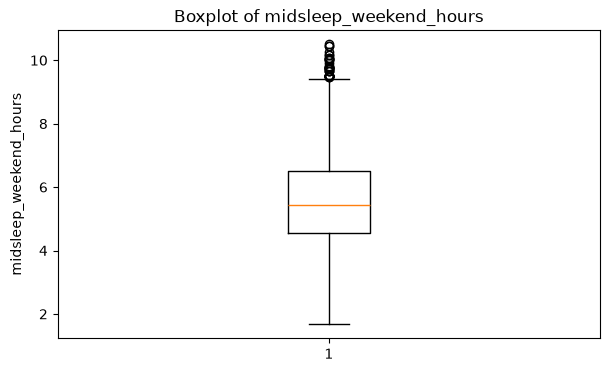

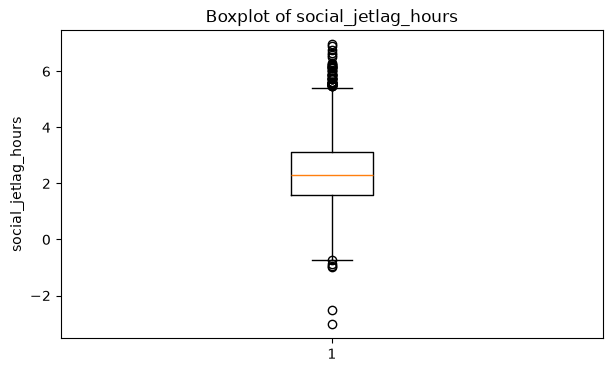

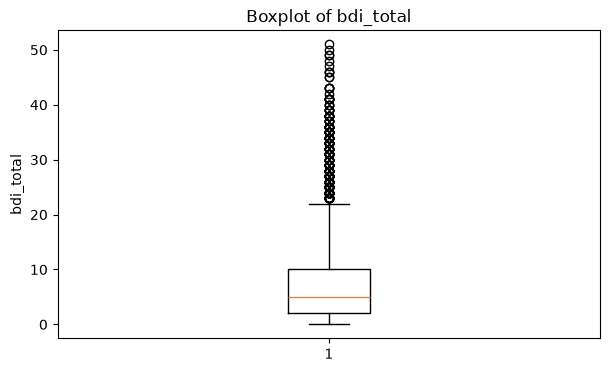

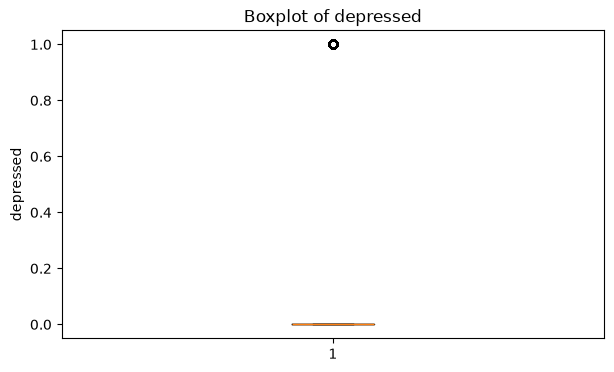

In [47]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [50]:
X = df.drop(columns=['depressed','bdi_total'])
y = df['depressed']

In [51]:
X.dtypes

sex                             str
screen_time_index           float64
est_leisure_screen_hours    float64
sleep_quality_index         float64
avg_sleep_hours             float64
midsleep_weekend_hours      float64
social_jetlag_hours         float64
dtype: object

In [52]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42, test_size=0.2, stratify=y)



In [54]:
X_train.shape, X_test.shape

((3848, 7), (962, 7))

# Create preprocessing pipeline Because sex is categorical and the other columns are numerical, we'll handle them separately.

In [55]:
from sklearn.compose import  ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_feature = ['sex']

numerical_features = [
    'screen_time_index',
    'est_leisure_screen_hours',
    'sleep_quality_index',
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'social_jetlag_hours'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'), categorical_feature)
    ]
)

In [ ]:
from sklearn.pipeline import